<a href="https://colab.research.google.com/github/brendanpshea/database_sql/blob/main/Database_01_StarShipSQL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Starship SQL: An Introduction to Databases
## Databases Through Pop Culture: Brendan Shea, PhD

This chapter introduces databases using Star Trek as an extended analogy. You will explore the distinctions between data, information, and knowledge; compare relational, document, and graph data models; walk through conceptual, logical, and physical modeling; and consider how DBMS choice, storage location, and analytical structures like data lakes, warehouses, and marts fit together.

## Learning Outcomes

By the end of this chapter, you will be able to:

1. Distinguish among data, information, and knowledge, and explain how databases help turn raw data into useful information.
2. Compare flat files and databases in terms of organization, consistency, and retrieval.
3. Differentiate conceptual, logical, and physical data models and identify entities and relationships in simple ERDs.
4. Compare relational, document, graph, and column-oriented data models and match them to appropriate use cases.
5. Evaluate factors involved in choosing a DBMS, including deployment choices such as local versus cloud systems.
6. Explain how databases relate to data lakes, data warehouses, and data marts.
7. Use a notebook environment to create a simple table, insert rows, and run basic retrieval, filtering, sorting, and counting queries with SQL.

## Video Lecture
You can click below to launch my lecture.

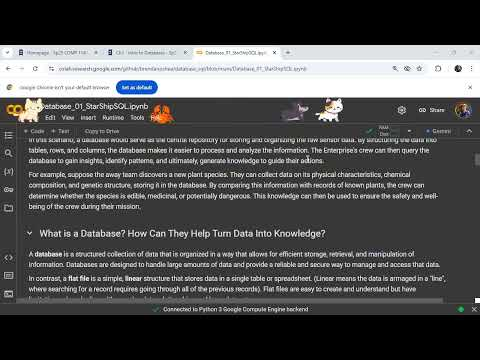

In [1]:
from IPython.display import YouTubeVideo
YouTubeVideo('ppa-ZFNQJH0', width=800, height=500)

## Introduction to the Case Study: Starship SQL

Welcome aboard the Starship Enterprise. Across this chapter, we will explore database concepts using examples from the adventures of the Enterprise and its crew.

Why a fictional spaceship? Because the same database ideas apply almost everywhere. Whether you are running a starship, a small business, or a global enterprise, the basics of storing, retrieving, and updating data look the same.

Setting the lessons aboard the Enterprise also makes abstract ideas easier to remember. We will see how databases help with concrete problems — organizing crew schedules, analyzing sensor data from a strange planet, tracking encounters with new species — and how the same patterns show up in everyday work.

## What's the Difference Between Data, Information, and Knowledge?

To understand databases, we must first distinguish three closely related terms: data, information, and knowledge. Consider the Enterprise's away team beaming down to an unexplored planet:
- We define **data** as raw, unorganized facts and figures. For instance, the ship's sensors might record isolated numbers like `295.2`, `1.013`, and `0.04`, which carry no meaning on their own.
- We define **information** as raw data that has been organized and given context so that it carries a clear meaning. By applying labels, the crew discovers that `295.2` is the temperature in Kelvin, `1.013` is the atmospheric pressure in bars, and `0.04` is the percentage of toxic chlorine gas in the air.
- We define **knowledge** as the practical understanding and actionable insights we gain by analyzing that information. Using the threat report, Spock determines that the planet is safe for human exploration without protective environmental suits, but warns the crew to avoid drinking the chlorinated surface water.

Without a way to store and organize data, we cannot easily convert raw sensor readings into useful knowledge. This is where databases come in.

## What is a Database? How Can They Help Turn Data Into Knowledge?

A **database** is a structured collection of data organized for efficient storage, retrieval, and updating. Databases are built to handle large volumes of information reliably and securely.

By contrast, a **flat file** is a simple, linear data file such as a single text table or spreadsheet. Flat files are easy to create, but they struggle to handle large datasets and complex relationships because searching for a record requires reading through rows one by one.

To understand the difference, imagine Starfleet Academy's library.
- In a **flat-file library**, every book is printed on a single, giant scroll. Finding a specific science officer's graduation record requires unrolling the entire scroll from the beginning.
- In a **relational database library**, records are split into separate tables (like dedicated catalog cards) and linked by unique identifiers, allowing the computer to jump directly to the exact record you need.

A relational database also enforces rules called **constraints** to ensure that data remains consistent and accurate, preventing duplicate records or orphaned entries when files are updated.

### Table: Database vs Flat Files
| **Criterion** | **Databases** | **Flat Files** |
| --- | --- | --- |
| **Data Structure** | Structured with tables, rows, and columns, allowing for complex relationships and queries. | Simple, often plain text or CSV format, with a linear structure and no inherent relationships. |
| **Data Integrity** | Enforced through constraints (e.g., primary keys, foreign keys), ensuring consistency and accuracy. | No built-in mechanisms for enforcing data integrity, leading to potential inconsistencies. |
| **Performance** | Optimized for large-scale data handling with indexing, caching, and query optimization features. | Limited performance, especially with large datasets, as each read/write requires file access. |
| **Concurrency** | Supports multiple concurrent users with transaction management, locking, and isolation levels. | Generally limited to single-user access, or requires complex mechanisms to manage concurrency. |
| **Scalability** | Designed to handle vast amounts of data and can scale horizontally (across servers) or vertically. | Limited scalability, as performance degrades significantly with larger datasets. |

**Interactive activity:** Open this standalone page to use the activity in the Jupyter Book or from Colab.

[Open the Data, Information, and Knowledge quiz](https://brendanpshea.github.io/database_sql/_static/games/data-information-knowledge-quiz.html)

## What is "Data Modeling"?

The first step in building any database is creating a **data model**. A data model is a standard blueprint that describes your data's structure, relationships, and business rules.

Creating a data model requires analyzing how your organization operates:
- We identify **entities**, which are the real-world objects, people, or events we need to store data about. For example, Starfleet might track **officers**, **starships**, and **missions**.
- We identify **attributes**, which are the specific characteristics that describe each entity, such as an officer's rank or a starship's registry number.
- We identify **relationships**, which describe how those entities connect to one another, such as recording which officer is assigned to serve on which starship.

By mapping out these connections, we build a data blueprint that ensures the physical database reflects real-world operations. We group data modeling into three progressive stages:
1. A **conceptual data model** is a high-level business overview that lists the main entities and how they connect, written in plain language.
2. A **logical data model** refines that overview into a concrete database structure (like tables and columns) without committing to a specific database software.
3. A **physical data model** is the actual implementation of that structure inside a specific database engine, specifying exact data types and physical storage settings.

### The Entity-Relationship Model

The **Entity-Relationship (ER) Model** is a visual way to describe data. It is used mainly in the conceptual and logical stages. ERDs are easy enough that technical and non-technical stakeholders can both validate them.

The key components are:

1. **Entities** — distinct objects or concepts (Mission, Starship, Crew Member).
2. **Attributes** — properties of an entity (mission start date, starship name, crew member rank).
3. **Relationships** — how entities connect (a Mission is assigned to a Starship).
4. **Cardinality** — how many of one entity relate to the other (one Starship can have many Missions, but each Mission belongs to one Starship).

ERDs fit into the modeling process in three stages:

- **Conceptual.** A high-level ER diagram shows the main entities and relationships, without all the attributes. Stakeholders use it to confirm the overall shape of the data.
- **Logical.** The diagram is refined with attributes, data types, and cardinality. This more detailed ER model bridges concept and implementation.
- **Physical.** The diagram becomes the actual schema in a chosen database. Entities become tables, attributes become columns, and relationships become primary and foreign keys.

Using the ER Model throughout keeps the data structure well-defined and easy for everyone to understand.

### Example: Conceptual ERD

In [2]:
# @title
import base64
import requests
from IPython.display import SVG, display, HTML

def mm(graph: str) -> None:
    """
    Fetch and display a Mermaid diagram as SVG.

    Parameters:
      graph (str): Mermaid graph definition.
    """
    # 1. Encode the graph to Base64
    b64 = base64.urlsafe_b64encode(graph.encode('utf-8')).decode('ascii')
    # 2. Construct the SVG URL
    url = f'https://mermaid.ink/svg/{b64}'
    # 3. Fetch SVG content
    svg_data = requests.get(url).text
    # 4. Render inline in Jupyter

    display(HTML(f'<div style="width: 50%">{svg_data}</div>'))

mm("""
  erDiagram
        MISSION ||--o{ CREW_MEMBER : "assigned to"
        MISSION ||--|| STARSHIP : "uses"
        MISSION }o--|| PLANET : "explores"
    """)

### Example: Logical ERD

In [3]:
# @title
mm("""
erDiagram
        MISSION_L {
            int mission_id PK
            date start_date
            date end_date
            string objective
            int starship_id FK
            int planet_id FK
        }
        STARSHIP_L {
            int starship_id PK
            string name
            string class
        }
        CREW_MEMBER_L {
            int crew_member_id PK
            string name
            string rank
        }
        PLANET_L {
            int planet_id PK
            string name
            string classification
        }
        MISSION_CREW_L {
            int mission_id FK
            int crew_member_id FK
        }
        MISSION_L ||--o{ MISSION_CREW_L : has
        MISSION_CREW_L }o--|| CREW_MEMBER_L : includes
        MISSION_L ||--|| STARSHIP_L : uses
        MISSION_L }o--|| PLANET_L : explores

""")

### Example: Physical ERD

In [4]:
# @title
mm("""
erDiagram
missions {
            serial mission_id PK
            date start_date
            date end_date
            varchar objective
            int starship_id FK
            int planet_id FK
        }
        starships {
            serial starship_id PK
            varchar name
            varchar class
        }
        crew_members {
            serial crew_member_id PK
            varchar name
            varchar rank
        }
        planets {
            serial planet_id PK
            varchar name
            varchar classification
        }
        mission_crew {
            int mission_id FK
            int crew_member_id FK
        }
        missions ||--o{ mission_crew : has
        mission_crew }o--|| crew_members : includes
        missions ||--|| starships : uses
        missions }o--|| planets : explores
""")

## Logical Data Models: The Relational Model

The **relational model** is the most widely used logical data model in modern applications. It organizes data into tables (often called **relations**), which consist of rows and columns.

### Relational terminology

Relational database theory uses formal terms to describe tables:
- A **relation** is a structured table containing rows and columns.
- An **attribute** is a named column in a table that represents a specific characteristic, such as a starship's name.
- A **tuple** is a single row in a table representing a unique record, such as a specific starship's specifications.
- A **primary key** is a unique identifier assigned to a column to ensure that no two rows in a table are identical, such as a starship's unique registry number.
- A **foreign key** is a column that references the primary key of another table to establish a clean relationship between them.

For example, Starfleet's starships table might look like this:

| registry (PK) | name | class | commissioning_date |
|---|---|---|---|
| NCC-1701 | USS Enterprise | Constitution | 2245-12-31 |
| NCC-1864 | USS Reliant | Miranda | 2264-03-15 |

To track assignments, we can use a separate personnel table:

| officer_id (PK) | name | rank | registry_assignment (FK) |
|---|---|---|---|
| 1 | James T. Kirk | Captain | NCC-1701 |
| 2 | Spock | Commander | NCC-1701 |

The foreign key column links Spock and Kirk directly to the USS Enterprise record in the starships table. By separating data into dedicated tables and linking them with keys, the relational model keeps data clean, organized, and free of redundant duplicates.

## Logical Data Models: JSON and Document Databases

**JSON (JavaScript Object Notation)** is a lightweight, text-based format for representing data. It is widely used in NoSQL databases, especially **document databases**. JSON is well-suited to semi-structured and hierarchical data.

In JSON, data is stored as **key-value pairs** and arrays. Keys are strings, and values can be strings, numbers, booleans, objects, or arrays. Because objects and arrays can nest, JSON supports complex hierarchical structures inside a single document.

```javascript

// Example of a JSON file
// Form is key : value
{
  "crew_id": "001",
  "name": "James Kirk",
  "rank": "Captain",
  "ship": "Enterprise",
  
  // Missions is an example of a "nested" data structure
  "missions": [
    {
      "mission_id": "M001",
      "planet": "Vulcan",
      "objective": "Diplomatic meeting",
      "start_date": "2258-01-15",
      "end_date": "2258-01-18"
    },
    {
      "mission_id": "M002",
      "planet": "Andoria",
      "objective": "Scientific research",
      "start_date": "2258-02-03",
      "end_date": "2258-02-07"
    }
  ],
  "skills": ["Leadership", "Tactics", "Diplomacy"],
  "performance_reviews": [
    {
      "date": "2258-12-31",
      "reviewer": "Admiral Pike",
      "rating": 9,
      "comments": "Exceptional leadership and decision-making skills."
    }
  ]
}

```

**Document databases** store data as semi-structured documents, typically using formats like JSON or BSON. Unlike relational tables, different documents in the same collection can have entirely different fields, which provides excellent schema flexibility.

### Key features of document databases

- The database uses a **schema-less** design where documents can add or change fields instantly without requiring expensive table migrations.
- The system supports **nested structures** to allow complex, hierarchical data (like a user's address list) to be stored inside a single document.
- The database is designed to **scale horizontally** by distributing documents across multiple servers, making it ideal for big-data applications.

### Logical Model: Graphs for Networks of Connected Information

Relational databases organize data into tables, while document databases nest related details inside single documents. **Graph databases** take a different approach: they store data as a **network of connected entities**. They shine when the relationships between things matter just as much as the things themselves.

### Understanding graph models

A graph database represents data as a visual network:
- We represent individual entities as **nodes** (or vertices), such as creating a node for Kirk, Spock, and the USS Enterprise.
- We connect these nodes using **edges** (or relationships) to describe how they relate, such as drawing a "reports_to" edge pointing from Spock to Kirk.
- We add extra details to nodes and edges by storing them as **properties**, such as adding `rank = "Captain"` to Kirk's node, or `started_date = "2265"` to Spock's reporting edge.

### Real-world applications

Graphs are excellent for analyzing complex, highly connected networks. Consider the diplomatic relations of the United Federation of Planets:
- Each member planet is a node, connected by trade agreements, military alliances, and cultural exchanges.
- Graph databases allow us to run relationship-heavy queries easily, such as finding the shortest diplomatic chain between two empires or identifying trade partners.
- We write graph queries using specialized languages like **Cypher** in Neo4j:

```cypher
MATCH (officer:Officer)-[:SERVES_ON]->(ship:Starship)
WHERE ship.name = "USS Enterprise"
RETURN officer.name, officer.rank
```

Alternatively, we can represent graph data as **RDF triples**, which describe relationships in a simple subject-predicate-object format:

```turtle
crew:kirk starfleet:servesOn ship:enterprise .
ship:enterprise starfleet:name "USS Enterprise" .
```

By focusing on paths and connections, graph databases handle relationship analysis far better than traditional tables.

In [5]:
# @title
mm("""
graph TD
    %% Officers
    Kirk[Captain Kirk]
    Spock[Commander Spock]
    McCoy[Dr. McCoy]
    Pike[Admiral Pike]

    %% Ships and Bases
    Enterprise[USS Enterprise]
    Base11[Starbase 11]

    %% Species and Planets
    Human[Humans]
    Vulcan[Vulcans]
    Earth[Earth]
    VulcanPlanet[Vulcan]

    %% Command Structure
    Pike -->|commands| Base11
    Kirk -->|reports to| Pike
    Kirk -->|commands| Enterprise
    Spock -->|reports to| Kirk
    McCoy -->|reports to| Kirk

    %% Ship Assignments
    Enterprise -->|docked at| Base11

    %% Species Relations
    Kirk -->|is a| Human
    Spock -->|is half| Vulcan
    Spock -->|is half| Human
    McCoy -->|is a| Human

    %% Planetary Relations
    Human -->|originates from| Earth
    Vulcan -->|originates from| VulcanPlanet

    %% Styling
    classDef officer fill:#f9f,stroke:#333
    classDef ship fill:#bbf,stroke:#333
    classDef base fill:#bfb,stroke:#333
    classDef species fill:#ffb,stroke:#333
    classDef planet fill:#bff,stroke:#333

    class Kirk,Spock,McCoy,Pike officer
    class Enterprise ship
    class Base11 base
    class Human,Vulcan species
    class Earth,VulcanPlanet planet
""")

## Other database types you should know

"Captain, four more data models deserve mention before we choose hardware," Spock notes. The relational, document, graph, and column-oriented models we have already met cover most production workloads, but specialty stores have grown up around specific problems.

- **Key-value databases** (Redis, Amazon DynamoDB) treat the entire store as one giant lookup table. The Enterprise's mission-status board, which has to read and write a small handful of values thousands of times a second, fits this model perfectly.
- **Vector databases** (pgvector, Pinecone) store high-dimensional numeric vectors and find the ones most similar to a query vector. Spock's similarity searches across alien language samples — "find the five recordings most like this one" — are a natural use case.
- **Time-series databases** (InfluxDB, TimescaleDB) are tuned for measurements that arrive in order, timestamped. The warp core's continuous telemetry — temperature, pressure, plasma flow — is a classic time-series workload.
- **Object-oriented databases** (db4o is the historical example) store entire programming objects, with inheritance and references preserved. The holodeck's serialized character library is the kind of nested object graph these were built for.

Most modern relational systems can simulate these patterns — Postgres supports key-value columns, JSON, and vector extensions — but specialized stores trade flexibility for speed in their niche. Knowing the categories exist is enough at this stage; you will not see them again until much later in the book.

## Logical Models: Columns for Analysis

Relational databases handle structured tables, while document databases store flexible JSON records. A third major approach, the **column-oriented** model, is designed specifically for high-speed analysis of massive datasets.

### The core idea: thinking in columns

Most relational databases use **row-oriented storage**, meaning that all columns of a single row are stored together on disk. This is excellent for operational tasks, such as looking up an officer's profile by ID.

However, analytical queries often need to calculate averages or sums across billions of rows but only look at a single column (such as calculating the average fuel consumption of an entire starfleet). In a row-oriented database, the computer must read every single column of every row, wasting time and resources.

A **column-oriented database** stores each column's data together on disk:
- The database only reads the specific columns requested by the query, which speeds up analysis of massive datasets.
- The database compresses data incredibly well because all values in a single column share the same data type.

By focusing on columns, these databases allow analysts to run high-speed reports across billions of records.

**Interactive activity:** Open this standalone page to use the activity in the Jupyter Book or from Colab.

[Open the Starship data model comparison](https://brendanpshea.github.io/database_sql/_static/games/starship-data-models.html)

## Structured, semistructured, and unstructured data

Before choosing storage, it helps to know what shape your data is in. Three broad categories cover almost everything:

- **Structured data** has a fixed schema: every record has the same fields in the same order. The Enterprise's crew roster — name, rank, department, hire date — is structured. Structured data lives naturally in a relational database.
- **Semistructured data** has tags or keys but no strict schema. A mission log might have a `timestamp` and a `summary` on every entry, but only some entries include a `casualty_count` or a `sensor_attachment`. Semistructured data fits document databases like MongoDB or JSON columns in Postgres.
- **Unstructured data** has no field structure at all — long text, audio, video, or images. The Enterprise's raw sensor video and free-text away-team reports are unstructured. Unstructured data typically lives in object storage with metadata in a database alongside.

| Shape | Example | Typical storage | Typical access pattern |
| --- | --- | --- | --- |
| Structured | Crew roster CSV | Relational tables | SQL queries with `WHERE`/`JOIN` |
| Semistructured | Mission log JSON | Document database or JSON column | Path expressions (`$.summary`) |
| Unstructured | Sensor video | Object storage + metadata table | Full file fetch + metadata lookup |

The choice of storage is mostly the choice of shape. As your projects grow, you will often combine all three.

## Physical Models: Choosing a DBMS

To store and manage data, you need a **Database Management System (DBMS)**, which is the software program that lets you create, organize, and interact with a database.

DBMS options vary based on the data models they support:
- A **Relational DBMS (RDBMS)** uses tables and SQL, which is the standard choice for financial records and structured operational data.
- A **Document DBMS** stores data in JSON documents, providing flexibility for web applications.
- A **Graph DBMS** maps out connections between nodes, making it ideal for network analysis and recommendation engines.
- A **Columnar DBMS** stores data in columns rather than rows, which is optimized for big-data analytics and warehousing.

Many modern database systems use a **multi-model** approach, allowing developers to query both relational tables and JSON documents inside the same database engine.

# Introduction to SQL: TV Shows Database Lab

## What is SQL?

**SQL (Structured Query Language)** is the standard language used to work with relational databases. It serves as the practical tool to create tables, store rows, and query data.

We divide SQL commands into a few key functional categories:
- We use **Data Definition Language (DDL)** commands, such as `CREATE TABLE` and `DROP TABLE`, to build and modify the database structure.
- We use **Data Manipulation Language (DML)** commands, such as `INSERT`, `UPDATE`, and `DELETE`, to add and edit records.
- We use **Data Query Language (DQL)** commands, primarily the `SELECT` statement, to filter, sort, and retrieve records.

In the following lab, you will use a notebook environment to write basic SQL queries against a sample database of TV shows.

In [6]:
%pip install --quiet jupysql
# Load SQL magic and connect to the chapter database
%load_ext sql
%config SqlMagic.autopandas = True
%sql sqlite:///movie.sqlite


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Connecting to 'sqlite:///movie.sqlite'

## SQL Instructions and Templates

### 1. Creating a Table
First, we need to create a table to store our TV show data. The CREATE TABLE command defines the structure of our table and the types of data it will store.

```sql
%%sql
CREATE TABLE shows (
    id INTEGER PRIMARY KEY,
    title TEXT,
    genre TEXT,
    release_year INTEGER,
    rating DECIMAL
);
```


In [7]:
%%sql
-- First, drop table if it already exists
DROP TABLE IF EXISTS shows;

Running query in 'sqlite:///movie.sqlite'

""


In [8]:
%%sql
CREATE TABLE shows (
    id INTEGER PRIMARY KEY,
    title TEXT,
    genre TEXT,
    release_year INTEGER,
    rating DECIMAL
);

Running query in 'sqlite:///movie.sqlite'

""



### 2. Adding Data: Single Row
To add one TV show to our database, we use the INSERT INTO command.

```sql
%%sql
INSERT INTO shows (title, genre, release_year, rating)
VALUES ('Your Show Title', 'Genre', 2024, 8.5);
```


In [9]:
%%sql
INSERT INTO shows (title, genre, release_year, rating)
VALUES ('Your Show Title', 'Your Genre', 2024, 8.5);

Running query in 'sqlite:///movie.sqlite'

1 rows affected.

""



### 3. Adding Multiple Rows
We can add multiple shows at once using multiple VALUES clauses.

```sql
%%sql
INSERT INTO shows (title, genre, release_year, rating)
VALUES
    ('First Show', 'Genre1', 2020, 8.5),
    ('Second Show', 'Genre2', 2021, 9.0),
    ('Third Show', 'Genre1', 2022, 7.8);
```


In [10]:
%%sql
INSERT INTO shows (title, genre, release_year, rating)
VALUES
    ('First Show', 'Genre1', 2020, 8.5),
    ('Second Show', 'Genre2', 2021, 9.0),
    ('Third Show', 'Genre1', 2022, 7.8);

Running query in 'sqlite:///movie.sqlite'

3 rows affected.

""



### 4. Retrieving All Data
To see all the data in our table, we use SELECT with an asterisk (*).

```sql
%%sql
SELECT * FROM shows;
```


In [11]:
%%sql
SELECT * FROM shows;

Running query in 'sqlite:///movie.sqlite'

,id,title,genre,release_year,rating
0,1,Your Show Title,Your Genre,2024,8.5
1,2,First Show,Genre1,2020,8.5
2,3,Second Show,Genre2,2021,9.0
3,4,Third Show,Genre1,2022,7.8



### 5. Selecting Specific Columns
We can retrieve only the columns we're interested in.

```sql
%%sql
SELECT title, rating
FROM shows;
```



In [12]:
%%sql
SELECT title, rating
FROM shows;

Running query in 'sqlite:///movie.sqlite'

,title,rating
0,Your Show Title,8.5
1,First Show,8.5
2,Second Show,9.0
3,Third Show,7.8



### 6. Filtering Data
The WHERE clause lets us filter our results based on conditions.

```sql
%%sql
SELECT title, genre, rating
FROM shows
WHERE rating >= 8.0;
```


In [13]:
%%sql
SELECT title, genre, rating
FROM shows
WHERE rating >= 8.0;

Running query in 'sqlite:///movie.sqlite'

,title,genre,rating
0,Your Show Title,Your Genre,8.5
1,First Show,Genre1,8.5
2,Second Show,Genre2,9.0



### 7. Sorting Data
ORDER BY helps us sort our results.

```sql
%%sql
SELECT title, release_year, rating
FROM shows
ORDER BY rating DESC;
```



In [14]:
%%sql
SELECT title, release_year, rating
FROM shows
ORDER BY rating DESC;

Running query in 'sqlite:///movie.sqlite'

,title,release_year,rating
0,Second Show,2021,9.0
1,Your Show Title,2024,8.5
2,First Show,2020,8.5
3,Third Show,2022,7.8


### 8. Counting Records
We can count how many shows meet certain criteria.

```sql
%%sql
SELECT COUNT(*) as show_count
FROM shows
WHERE genre = 'Your Genre';
```

In [15]:
%%sql
SELECT COUNT(*) as show_count
FROM shows
WHERE genre = 'Your Genre';

Running query in 'sqlite:///movie.sqlite'

,show_count
0,1



### 10. Updating Data
We can modify existing data using the UPDATE command.

```sql
%%sql
UPDATE shows
SET rating = 9.5
WHERE title = 'Your Show Title';
```


In [16]:
%%sql
UPDATE shows
SET rating = 9.5
WHERE title = 'Your Show Title';

Running query in 'sqlite:///movie.sqlite'

1 rows affected.

""


In [17]:
%%sql
-- Now, see the results.
SELECT * FROM shows;

Running query in 'sqlite:///movie.sqlite'

,id,title,genre,release_year,rating
0,1,Your Show Title,Your Genre,2024,9.5
1,2,First Show,Genre1,2020,8.5
2,3,Second Show,Genre2,2021,9.0
3,4,Third Show,Genre1,2022,7.8


### 11. Using AI to Generate Sample Data

The **Gemini** AI built into Colab can help you generate realistic TV show data. Here's the workflow:

1. Open the Gemini window and type a prompt describing what you want:

   ```text
   Generate 10 INSERT statements for the shows table with realistic TV show data.
   Include popular shows from different genres and years.
   Format: INSERT INTO shows (title, genre, release_year, rating) VALUES ('title', 'genre', year, rating);
   ```

2. Let Gemini draft the INSERT statements. You might get something like:

   ```sql
   INSERT INTO shows (title, genre, release_year, rating) VALUES
   ('Breaking Bad', 'Drama', 2008, 9.5),
   ('The Office', 'Comedy', 2005, 8.9),
   ('Stranger Things', 'Sci-Fi', 2016, 8.7),
   ('The Crown', 'Drama', 2016, 8.6),
   ('Friends', 'Comedy', 1994, 8.8);
   ```

3. Review the suggestions and edit as needed. You can also ask Gemini to:
   - Cover more genres.
   - Focus on a specific decade.
   - Restrict the rating range.

Tips for working with AI:

- Be specific in your prompt.
- Spot-check the data for accuracy.
- Ask for more examples or different shapes if needed.
- Verify the SQL syntax before running it.

In [18]:
%%sql
INSERT INTO shows (title, genre, release_year, rating) VALUES
('Breaking Bad', 'Drama', 2008, 9.5),
('The Office', 'Comedy', 2005, 8.9),
('Stranger Things', 'Sci-Fi', 2016, 8.7),
('The Crown', 'Drama', 2016, 8.6),
('Friends', 'Comedy', 1994, 8.8);

Running query in 'sqlite:///movie.sqlite'

5 rows affected.

""


In [19]:
%%sql
SELECT * FROM shows;

Running query in 'sqlite:///movie.sqlite'

,id,title,genre,release_year,rating
0,1,Your Show Title,Your Genre,2024,9.5
1,2,First Show,Genre1,2020,8.5
2,3,Second Show,Genre2,2021,9.0
3,4,Third Show,Genre1,2022,7.8
4,5,Breaking Bad,Drama,2008,9.5
5,6,The Office,Comedy,2005,8.9
6,7,Stranger Things,Sci-Fi,2016,8.7
7,8,The Crown,Drama,2016,8.6
8,9,Friends,Comedy,1994,8.8


### 12. Pattern Matching with LIKE
The LIKE operator is a powerful tool for searching text patterns. It uses two special characters:
- `%` matches any sequence of characters (including zero characters)
- `_` matches exactly one character

Here are some useful pattern matching examples:

```sql
%%sql
-- Find shows that start with "The"
SELECT title FROM shows WHERE title LIKE 'The%';

-- Find shows that end with "Show"
SELECT title FROM shows WHERE title LIKE '%Show';

-- Find shows with "and" anywhere in the title
SELECT title FROM shows WHERE title LIKE '%and%';

-- Find shows with exactly 5 characters
SELECT title FROM shows WHERE title LIKE '_____';

-- Find shows that start with 'B' and have 'r' as the third letter
SELECT title FROM shows WHERE title LIKE 'B_r%';
```

Write a query using LIKE

In [20]:
%%sql
SELECT title
FROM shows
WHERE title LIKE 'The%';

Running query in 'sqlite:///movie.sqlite'

,title
0,The Office
1,The Crown


## 13. Have Fun!
You've learned the basics of SQL (we'll learn lots more as we go through the class). Now, it's your turn to play with it. Make a new table about a topic that interests you, and see what you can discover.

In [21]:
%%sql
SELECT 'Student workspace: Replace this scaffold with your own SQL.' AS note;

Running query in 'sqlite:///movie.sqlite'

,note
0,Student workspace: Replace this scaffold with ...


In [22]:
%%sql
SELECT 'Student workspace: Replace this scaffold with your own SQL.' AS note;

Running query in 'sqlite:///movie.sqlite'

,note
0,Student workspace: Replace this scaffold with ...


In [23]:
%%sql
SELECT 'Student workspace: Replace this scaffold with your own SQL.' AS note;

Running query in 'sqlite:///movie.sqlite'

,note
0,Student workspace: Replace this scaffold with ...


### Table: Leading Database Management Systems
| DBMS | Description | Supported Logical Models |
| --- | --- | --- |
| Oracle | A powerful, enterprise-level database system known for its scalability and reliability, often used by large organizations. | Relational, JSON, XML, Spatial |
| MySQL | A popular, open-source database system widely used for web applications, offering simplicity and good performance. | Relational, JSON (MySQL 5.7+) |
| Microsoft SQL Server | A robust database system developed by Microsoft, providing scalability, security, and integration with other Microsoft products. | Relational, JSON (SQL Server 2016+), XML, Spatial |
| Microsoft Access | A user-friendly, small-scale database system included in the Microsoft Office suite, suitable for personal projects and small businesses. | Relational |
| SQLite | A lightweight, file-based database system commonly used as an embedded database in applications, known for its simplicity and efficiency. | Relational, JSON (partial) |
| MongoDB | A flexible, document-oriented NoSQL database that stores data in JSON-like formats, designed for scalability and agile development. | Document (JSON), Geospatial |
| Apache Cassandra | A highly scalable, distributed NoSQL database built to handle large amounts of structured data across multiple servers. | Wide Column Store |
| Amazon DynamoDB | A fully managed NoSQL database service provided by Amazon Web Services, offering automatic scaling and low latency data access. | Key-value, Document (JSON) |
| PostgreSQL | A powerful, open-source database system known for its reliability, robustness, and support for advanced data types. | Relational, JSON, XML, Spatial, Key-value (Hstore) |
| IBM Db2 | An enterprise-level database system developed by IBM, offering scalability, reliability, and advanced analytics capabilities. | Relational, JSON, XML, Spatial |

## Advanced Data Storage Concepts

To manage data at scale, organizations use different storage architectures: databases, data lakes, data warehouses, and data marts.

- A **relational database** is our transactional foundation, which is designed to process day-to-day operations using structured tables and ACID transactions.
- A **data lake** is a massive repository that stores raw, unorganized data (such as sensor logs, images, and documents) in its original format until someone needs it.
- A **data warehouse** is a central analytical repository that pulls data from many different sources, cleans it, and structures it using an **Extract, Transform, Load (ETL)** process.
- A **data mart** is a smaller, targeted slice of a data warehouse focused on a single business department (such as a sales team), which speeds up queries and improves security.

In a Starfleet scenario, a starship might write its real-time sensor logs to a local database. All starship logs are later merged into a massive Federation data lake, which analysts clean and load into a central Starfleet data warehouse. Finally, specific departments (like Engineering or Security) query their own dedicated data marts to analyze fleet trends.

In [24]:
# @title
mm("""
graph TD
    A[Transactional Databases<-  Store day-to-day operations.<br>Examples: Crew logs, replicator orders, sensor data.]
    -->|ETL Process  - Extract, Transform, Load| B[Data Warehouse - Stores structured data for analysis.<br>Examples: Analyzing energy use or mission trends.]
    A -->|Raw Data Ingestion - Store as-is| C[Data Lake - Stores raw, unstructured data.<br>Examples: Sensor scans, raw logs, probe data.]
    C -->|Transform Data - Process for analysis| B
    B -->|Specific Subset - Focused Data| D[Data Mart - Specialized part of a data warehouse.<br>Examples: Warp core analysis for engineering.]

""")

**Interactive activity:** Open this standalone page to use the activity in the Jupyter Book or from Colab.

[Open the data storage systems quiz](https://brendanpshea.github.io/database_sql/_static/games/data-storage-systems-quiz.html)

## Chapter Summary

Use this list as a self-check. After working through the chapter, you should be able to do each of the following:

- You can distinguish data, information, and knowledge, and explain how databases turn data into knowledge.
- You can name the advantages databases offer over flat files for organization, retrieval, and consistency.
- You can describe the conceptual, logical, and physical levels of data modeling.
- You can compare relational, document (JSON), and graph data models and pick one for a given scenario.
- You can weigh DBMS choices and the trade-offs between cloud and local storage.
- You can explain how databases, data lakes, data warehouses, and data marts relate to one another.
- You can recognize key-value, vector, time-series, and object-oriented databases and name a use case for each.
- You can sort data into structured, semistructured, and unstructured categories and explain why the category matters.

## Practice with the Loop of the Recursive Dragon

Sharpen what you just learned with a chapter-matched review set in the **Loop of the Recursive Dragon** — an adaptive review game with multiple question types and RPG-style mechanics, built for this book.

[**Launch the Chapter 1 review set →**](https://brendanpshea.github.io/LotRD/?set=database_01_foundations.json)

## Glossary

Use this reference sheet to quickly review key terms from this chapter.

- **Data** is raw, unorganized facts and figures that carry no meaning on their own.
- **Information** is data that has been organized, structured, and labeled so that it carries a clear meaning.
- **Knowledge** is the practical understanding and actionable insights gained by analyzing information.
- A **database** is a structured collection of data organized for efficient storage, retrieval, and updating.
- A **flat file** is a simple, linear data file where searching requires scanning rows one by one.
- A **relational database** is a database that organizes data into tables of rows and columns linked by unique keys.
- A **data model** is a standard blueprint that describes a database's structure, relationships, and rules.
- An **entity** is a real-world object, person, or event that we store data about in a database.
- An **attribute** is a specific column in a table that represents a characteristic of an entity.
- A **relationship** describes how different database entities connect to one another.
- A **conceptual data model** is a high-level business overview of entities and relationships in plain language.
- A **logical data model** is a concrete database layout (like tables and columns) independent of specific software.
- A **physical data model** is the actual implementation of a database layout inside a specific database engine.
- A **relation** is a formal database term for a structured table of rows and columns.
- A **tuple** is a formal database term for a single row in a table.
- A **primary key** is a unique column value used to identify each row in a table.
- A **foreign key** is a column that references another table's primary key to link them together.
- A **document database** is a NoSQL database that stores data in flexible, semi-structured JSON documents.
- A **graph database** is a NoSQL database that stores data as a network of nodes, edges, and properties.
- A **node** is a point in a graph database representing a specific entity.
- An **edge** is a link in a graph database representing a relationship between two nodes.
- A **property** is a key-value detail stored on a node or an edge in a graph database.
- A **column-oriented database** is an analytical database that stores each column's data together on disk.
- A **Database Management System (DBMS)** is the software program used to manage and interact with a database.
- A **static IP** is a permanent, unchanging network address manually assigned to a database server.
- A **dynamic IP** is a temporary network address assigned automatically that can change over time.
- **SQL** is the standard Structured Query Language used to query and modify relational databases.
- A **data lake** is a massive repository that stores raw, unorganized data in its original format.
- A **data warehouse** is a central analytical repository that stores integrated historical data from multiple sources.
- A **data mart** is a smaller, targeted slice of a data warehouse focused on a single business department.